# **DSCI235 Final Project**

https://github.com/CallahanRiddick/DSCI235-Final-Project-House-Price-Analysis.git 

### **Introduction**

I have a major interest in both data analytics and economics. Therefore, in this project, I will be exploring the Washington housing market and determining what factors contribute the most to a home's price. The data I found for this is a data set with 4139 Washington properties. It has 18 total features, including price, # bedrooms, # bathrooms, square footage, city, etc. Using these features, I intend to determine trends and patterns, along with what factors correlate to housing prices.


In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Exploration and Cleaning

Immediately, this data looked fairly clean, but regardless, I still need to double-check and make sure there aren't any missing or incorrect values.

In [225]:
data = pd.read_csv("USA Housing Dataset.csv")
data.info

<bound method DataFrame.info of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-09 00:00:00  3.760000e+05       3.0       2.00         1340   
1     2014-05-09 00:00:00  8.000000e+05       4.0       3.25         3540   
2     2014-05-09 00:00:00  2.238888e+06       5.0       6.50         7270   
3     2014-05-09 00:00:00  3.240000e+05       3.0       2.25          998   
4     2014-05-10 00:00:00  5.499000e+05       5.0       2.75         3060   
...                   ...           ...       ...        ...          ...   
4135  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4136  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4137  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4138  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4139  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  c

In [226]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.140000e+03,4140.000000,4140.000000,4140.000000,4.140000e+03,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000
mean,5.530629e+05,3.400483,2.163043,2143.638889,1.469764e+04,1.514130,0.007488,0.246618,3.452415,1831.351449,312.287440,1970.814010,808.368357
std,5.836865e+05,0.903939,0.784733,957.481621,3.587684e+04,0.534941,0.086219,0.790619,0.678533,861.382947,464.349222,29.807941,979.380535
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.200000e+05,3.000000,1.750000,1470.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.600000e+05,3.000000,2.250000,1980.000000,7.676000e+03,1.500000,0.000000,0.000000,3.000000,1600.000000,0.000000,1976.000000,0.000000
75%,6.591250e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2310.000000,602.500000,1997.000000,1999.000000
max,2.659000e+07,8.000000,6.750000,10040.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,4820.000000,2014.000000,2014.000000


In [227]:
data.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [228]:
(data["price"] == 0).sum()

np.int64(49)

In [229]:
zero_price_housing = data[data["price"] == 0]
zero_price_housing

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
3894,2014-05-05 00:00:00,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
3896,2014-05-05 00:00:00,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
3897,2014-05-05 00:00:00,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
3898,2014-05-06 00:00:00,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
3901,2014-05-07 00:00:00,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA
3902,2014-05-07 00:00:00,0.0,4.0,4.00,3680,18804,2.0,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA
3914,2014-05-09 00:00:00,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,USA
3916,2014-05-09 00:00:00,0.0,4.0,2.25,2170,10500,1.0,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,USA
3922,2014-05-12 00:00:00,0.0,5.0,4.50,4630,6324,2.0,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA
3923,2014-05-13 00:00:00,0.0,5.0,4.00,4430,9000,2.0,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,USA


In [230]:
data = data[data["price"] > 0]

In [231]:
(data["bedrooms"] == 0).sum()

np.int64(2)

In [232]:
zero_bed_housing = data[data["bedrooms"] == 0]
zero_bed_housing

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1905,2014-06-12 00:00:00,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
2749,2014-06-24 00:00:00,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [233]:
data = data[data["bedrooms"] > 0]

In [234]:
(data["bathrooms"] == 0).sum()

np.int64(0)

In [235]:
zero_bath_housing = data[data["bedrooms"] == 0]
zero_bath_housing

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country


After looking into the data, I discovered there were a number of houses with pricing set to 0, which doesn't make sense and likely indicates missing data, so I removed the 49 homes that had price as zero. Additionally, I removed the 2 homes which were stated to have 0 bedrooms since that also looks like missing data and won't help when determining correlation between features. Now that the data is cleaned up, I can start answering the interesting question of what factors affect housing prices.

### **Exploring What House Factors Affect Prices** ### 

Now that the data has been cleaned up and the missing or illogical values have been removed its time to figure out what factors have a significant impact on a house's price using visualizations and correlation calculations.

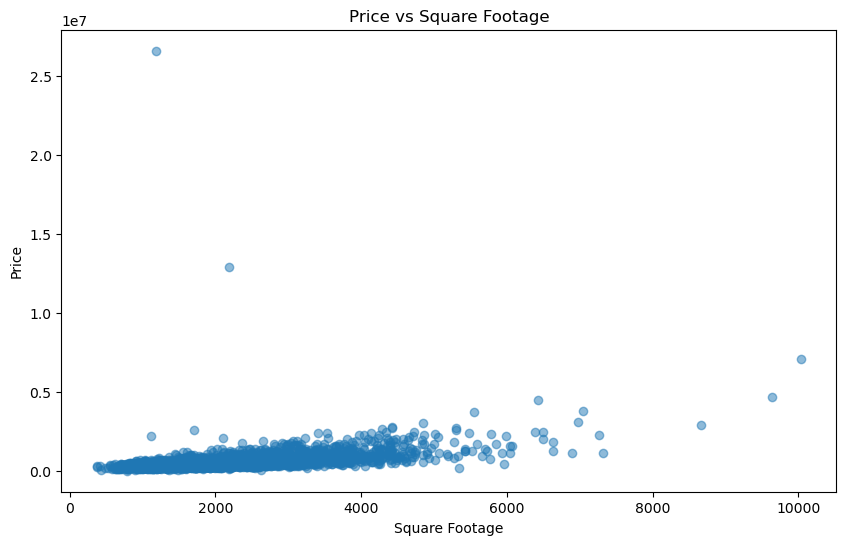

In [236]:
plt.figure(figsize = (10, 6))
plt.scatter(data["sqft_living"], data["price"], alpha = 0.5)
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.title("Price vs Square Footage")
plt.show()

We can see that there is some correlation between square footage and price. When graphed, we see there is a bit of a trend, but it could be visualized better without the outliers. 

In [237]:
data = data[~((data['price'] > 1000000) & (data['sqft_living'] < 2500))]

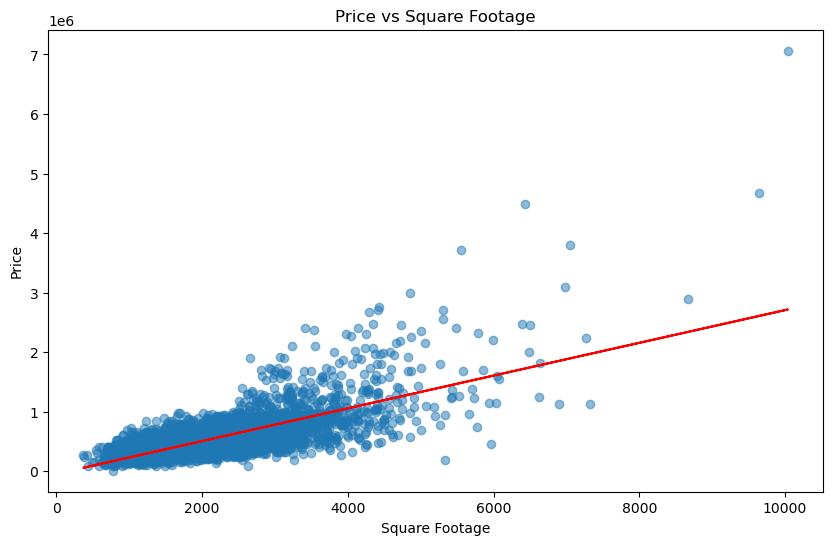

In [238]:
x = data["sqft_living"]
y = data["price"]
plt.figure(figsize = (10, 6))
plt.scatter(x, y, alpha = 0.5)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color = "red")
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.title("Price vs Square Footage")
plt.show()

After removing the outliers and adding a line of best fit, this is a much better visualization that shows the correlation between the two is significant based on the upward trend that the data follows. Logically, this makes sense as the more square footage a house has, the more you'd pay since you're getting a larger house. However, there are lots of factors to price outside of just size, so we need to check those as well. Next, we will check the price distribution by bedrooms.

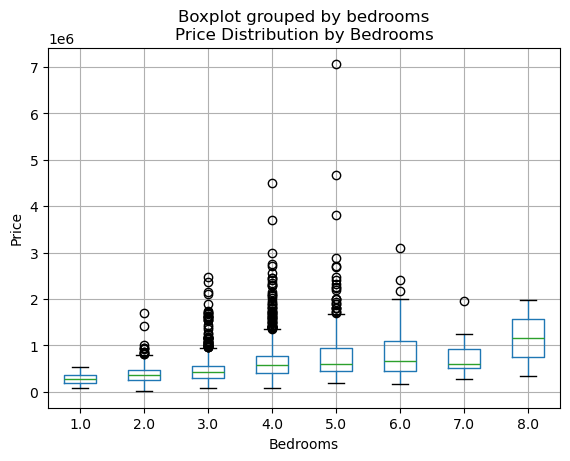

In [239]:
data.groupby("bedrooms")["price"].mean()
data.boxplot(column = "price", by = "bedrooms")

plt.title("Price Distribution by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

This is a good visualization, but again there is one outlier that is priced extremely high. While it's probably just a very high luxury house I am looking to answer questions about the general USA housing market, meaning this is an outlier I can safely remove to improve the visualization.

In [240]:
data = data[data['price'] < 7000000]

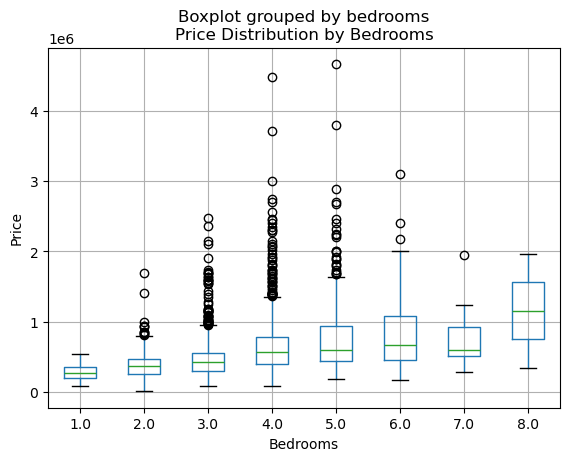

In [241]:
data.groupby("bedrooms")["price"].mean()
data.boxplot(column = "price", by = "bedrooms")

plt.title("Price Distribution by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

This looks far better and is easier to read. I used a box plot since it would allow for easier analysis. Here we can see that as the number of bedrooms increases, we see an increase in the median house price; however, there is a significant amount of overlap between groups, demonstrating that while the number of bedrooms is impactful, it is not the strongest factor in determining a home's value. Next I will do the same check but for the number of bathrooms a home has. 

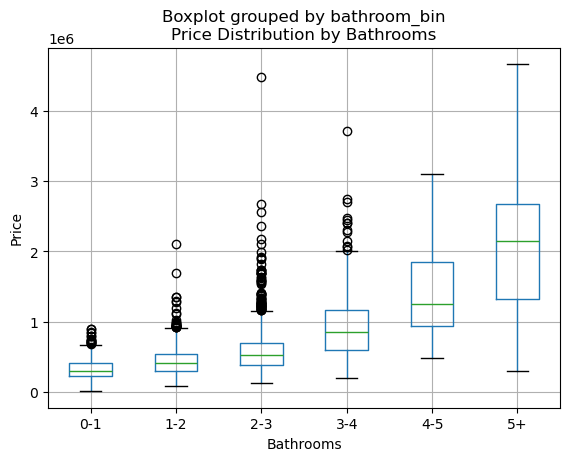

In [242]:
bins = [0, 1, 2, 3, 4, 5, 7]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5+"]

data["bathroom_bin"] = pd.cut(data["bathrooms"], bins = bins, labels = labels)

data.boxplot(column = "price", by = "bathroom_bin")

plt.title("Price Distribution by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

When making a box plot with the number of bathrooms, we again see that there is a consistent increase in median home value as the number of bathrooms increases, showing that they are indeed a valid predictor of house prices. While there is still some overlap to indicate that bathrooms alone don't explain housing costs, by grouping the number of bathrooms into bins, it is far easier to see that there is a consistent upward trend, and bathrooms are one of the strongest factors. I will now use the correlation function to confirm my analysis.

In [243]:
data.corr(numeric_only = True)["price"].sort_values(ascending = False)

price            1.000000
sqft_living      0.714623
sqft_above       0.607364
bathrooms        0.548872
view             0.377081
bedrooms         0.344950
sqft_basement    0.344051
floors           0.259545
waterfront       0.191964
sqft_lot         0.083366
yr_built         0.053929
condition        0.049335
yr_renovated    -0.055702
Name: price, dtype: float64

This shows the correlation score of each factor when correlated to price, with the closer to 1 scores indicating a higher positive correlation. Here, we can see our analysis has been accurate, as sqft_living has an extremely high correlation to price, along with bathrooms showing a strong correlation and bedrooms showing some correlation. 

## **Exploring Locational Factors** ### 

I now want to consider the factors outside the house itself, such as whether it's a waterfront property, what the view looks like, and what city it is in. This is important because the location of a house can drastically vary the price. For example, a mansion in the middle of nowhere is likely cheaper than an average home in California due to the different values of the locations. Speaking of California, I will start by looking into the difference between properties that do and don't have waterfront properties. 

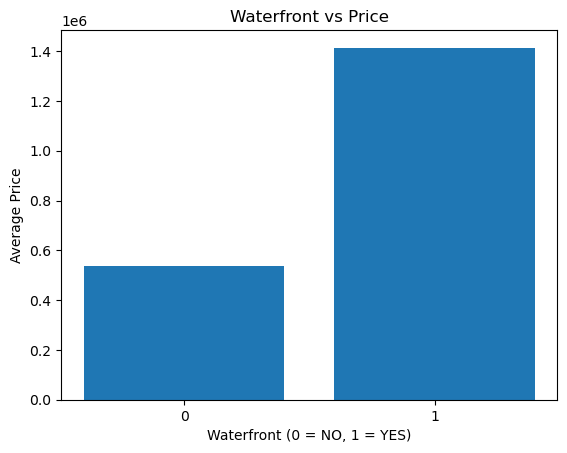

In [244]:
waterfront_avg = data.groupby("waterfront")["price"].mean()
plt.bar(waterfront_avg.index.astype(str), waterfront_avg.values)
plt.xlabel("Waterfront (0 = NO, 1 = YES)")
plt.ylabel("Average Price")
plt.title("Waterfront vs Price")
plt.show()

The graph is fairly self-explanatory, but as expected, on average properties with a waterfront are valued almost 3 times higher than those that lack a waterfront. This is a good way to represent the impact location can have on price. Now, let's consider how the view impacts price.

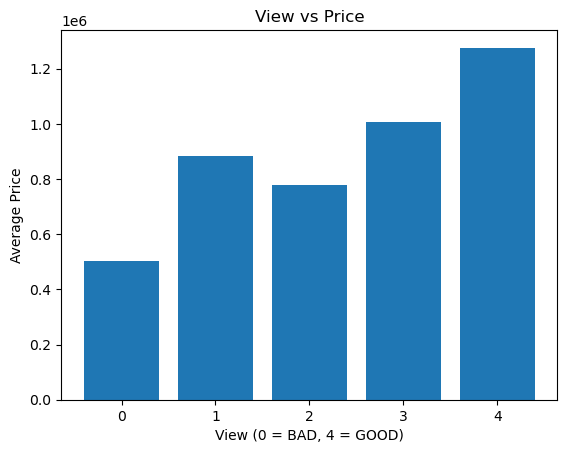

In [245]:
view_avg = data.groupby("view")["price"].mean()
plt.bar(view_avg.index.astype(str), view_avg.values)
plt.xlabel("View (0 = BAD, 4 = GOOD)")
plt.ylabel("Average Price")
plt.title("View vs Price")
plt.show()

Here we can see an upward trend that tells us that on average as the view improves the price also increases. It appears that the value of a great view is about 2.5 times as much as a bad view, which again demonstrates how much value can be added to a home simply by the location around it. The final factor of location to consider is the city the property is in.

In [246]:
data.groupby("city")["price"].mean().sort_values(ascending = False)

city
Medina                2.046559e+06
Clyde Hill            1.678925e+06
Yarrow Point          1.194838e+06
Mercer Island         1.169711e+06
Bellevue              8.471392e+05
Fall City             7.788333e+05
Beaux Arts Village    7.450000e+05
Sammamish             6.923626e+05
Newcastle             6.731424e+05
Redmond               6.575065e+05
Kirkland              6.537511e+05
Woodinville           6.128316e+05
Issaquah              6.036765e+05
Preston               5.624500e+05
Seattle               5.624443e+05
Ravensdale            5.571250e+05
Snoqualmie            5.570425e+05
Normandy Park         5.381183e+05
Carnation             5.300857e+05
Snoqualmie Pass       5.250000e+05
Vashon                4.803268e+05
Bothell               4.796694e+05
Lake Forest Park      4.702290e+05
Kenmore               4.484773e+05
Black Diamond         4.280833e+05
Shoreline             4.196590e+05
Duvall                4.084065e+05
North Bend            4.057732e+05
Renton         

This is a start but to get a fair evaluation I will remove all cities with less than 20 properties so that the data isn't skewed by one small rich city.

In [247]:
data["city"].value_counts()

city
Seattle               1380
Renton                 259
Bellevue               246
Redmond                207
Kent                   165
Kirkland               164
Issaquah               161
Auburn                 161
Sammamish              153
Federal Way            128
Shoreline              112
Woodinville            102
Maple Valley            89
Mercer Island           75
Snoqualmie              63
Burien                  62
Kenmore                 57
Des Moines              52
North Bend              45
Duvall                  39
Covington               37
Lake Forest Park        31
Newcastle               31
Bothell                 30
SeaTac                  28
Vashon                  28
Tukwila                 27
Enumclaw                27
Carnation               18
Normandy Park           15
Medina                  11
Fall City                9
Clyde Hill               8
Black Diamond            6
Pacific                  6
Yarrow Point             4
Ravensdale             

In [248]:
city_counts = data["city"].value_counts()
valid_cities = city_counts[city_counts > 20].index
filtered_data = data[data["city"].isin(valid_cities)]

In [249]:
filtered_data.groupby("city")["price"].mean().sort_values(ascending=False)

city
Mercer Island       1.169711e+06
Bellevue            8.471392e+05
Sammamish           6.923626e+05
Newcastle           6.731424e+05
Redmond             6.575065e+05
Kirkland            6.537511e+05
Woodinville         6.128316e+05
Issaquah            6.036765e+05
Seattle             5.624443e+05
Snoqualmie          5.570425e+05
Vashon              4.803268e+05
Bothell             4.796694e+05
Lake Forest Park    4.702290e+05
Kenmore             4.484773e+05
Shoreline           4.196590e+05
Duvall              4.084065e+05
North Bend          4.057732e+05
Renton              3.740533e+05
Burien              3.584257e+05
Maple Valley        3.409825e+05
Enumclaw            3.190077e+05
Des Moines          3.088023e+05
Auburn              2.984998e+05
Kent                2.982140e+05
Federal Way         2.945588e+05
Covington           2.587840e+05
SeaTac              2.540510e+05
Tukwila             2.444967e+05
Name: price, dtype: float64

Now that I have the average price for a property in each city, I will visualize the 10 most expensive and the 10 cheapest cities to live in.

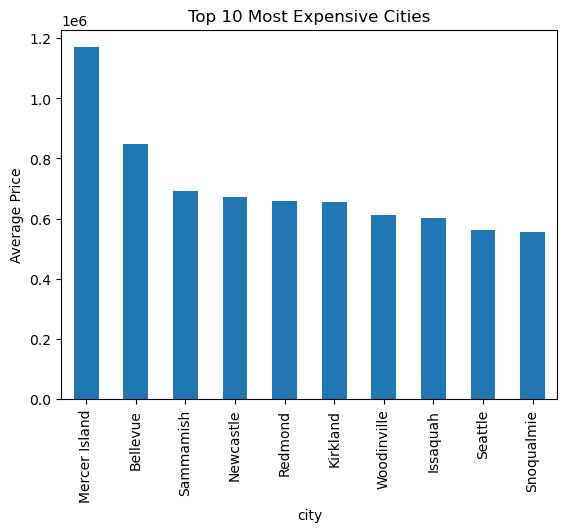

In [250]:
big_cities = filtered_data.groupby("city")["price"].mean().sort_values(ascending=False).head(10)
big_cities.plot(kind = "bar")
plt.title("Top 10 Most Expensive Cities")
plt.ylabel("Average Price")
plt.show()

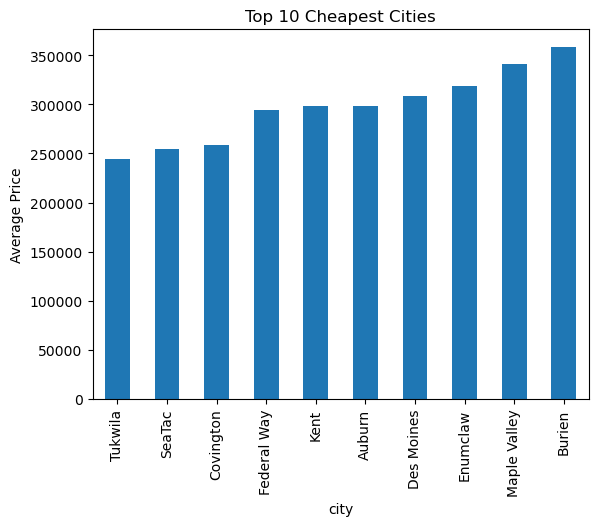

In [251]:
small_cities = filtered_data.groupby("city")["price"].mean().sort_values().head(10)
small_cities.plot(kind = "bar")
plt.title("Top 10 Cheapest Cities")
plt.ylabel("Average Price")
plt.show()

After visualizing the 10 most expensive and 10 cheapest cities to live in, there are some clear patterns that need to be addressed. First of all, out of the 10 most expensive cities to live in, 9 are cities that geographically are located near water fronts and good views, which makes sense based on our previous data showing how much value these qualities add to the average price of a home. As expected, the 10 cheapest cities to live in all lack these features, and therefore, the average value of a home is significantly lower in these areas. While it is difficult to determine exactly how much value living in a specific city brings, by looking at the most expensive cities to live in, we can see vast differences in average cost between cities that share the locational benefits previously mentioned. This demonstrates that there is an impact on price based on the city, regardless of additional factors.

### **Exploring How Condition Affect Housing Prices** ### 

The last factor I think needs to be addressed is the current condition of the house as obviously not every house is new and the state of the house will help determine how much a person wants to spend on it.

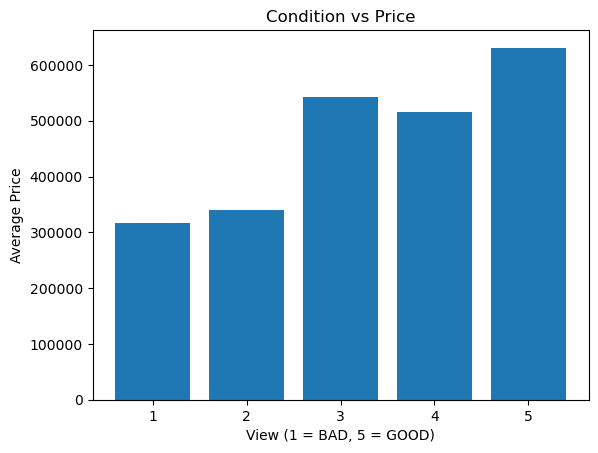

In [252]:
condition_avg = data.groupby("condition")["price"].mean()
plt.bar(condition_avg.index.astype(str), condition_avg.values)
plt.xlabel("View (1 = BAD, 5 = GOOD)")
plt.ylabel("Average Price")
plt.title("Condition vs Price")
plt.show()

As expected, there is a clear trend that shows an increase in the average price of a home as the condition improves. It should be noted that the difference in value between a house in bad condition and one in great condition is nearly 2 times. While this is less impactful than waterfronts and views, it is still an additional way to add value to a house.

### **Conclusion** ### 

Overall, while there are a ton of factors that show significant correlation to determining the value of a house, some are more significant than others. In our analysis, we looked into three different types of factors such as the house itself, the location of the property, and the condition it was in. We discovered that in terms of the house itself, the square footage was the best predictor of price, with the number of bathrooms also being significant and the number of bedrooms being mildly significant. In terms of location, I determined that having a waterfront or a great view can both increase the average value of the home by roughly 2.5 times compared to not having these features. While cities demonstrated an impact on price, it was far less significant than the impact of water fronts and great views. The last factor I looked into was the condition, which naturally showed an increase in average price as conditions improved.

With a data set of this size and this many factors, there is a ton of additional analysis that can be done and plenty of data to construct a prediction model for house prices if someone wanted to take this project to the next level.